In [1]:
import sys
sys.path.append('..')
from osp import *

In [2]:
df_meta = get_corpus_metadata()
periods = sorted(df_meta.period.unique())
disciplines = ['Philosophy', 'Literature', 'Other']

In [3]:
comparisons = []
done = set()
for d1_i in range(len(disciplines)):
    d1 = disciplines[d1_i]
    for d2_i in range(len(disciplines)):
        d2 = disciplines[d2_i]
        
        for period1 in periods:
            for period2 in periods:
                if period1==period2 and d1==d2: continue

                key = tuple(sorted([period1, period2, d1, d2]))
                if key in done: continue
                done.add(key)

                name1 = f"{period1} {d1}"
                name2 = f"{period2} {d2}"
                name = f"{name1} vs {name2}"
                query1 = f'discipline=="{d1}" & period=="{period1}"'
                query2 = f'discipline=="{d2}" & period=="{period2}"'
                comparisons.append(((name1, query1), (name2, query2)))

len(comparisons)

75

In [4]:
STASH_SLICE_FEATS

Config,Param,Value
Path,Root Dir,/Users/rj416/github/ordinary-style-philosophy/data/raw/stash/osp_slices_1000_feats
,Filename,data.db
Engine,Engine,lmdb
,Serializer,hashstash
,Compress,lz4
,B64,True
Stats,Len,76776


In [5]:
df_preds, df_feats = classify_then_predict_comparisons(
    comparisons, 
    also_predict_unseen=True, 
    num_runs=10, 
    sample_size=1000, 
    feat_n=25,
    feat_n_egs=10, 
    normalize=NORMALIZE_CLASSIFY_DATA,
    num_proc=1
)

Classifying comparisons: 100%|██████████| 75/75 [10:31<00:00,  8.42s/it]


In [6]:
# df_preds

In [7]:
def get_df_probs(df_preds):
    l = []
    for i,r in df_preds.iterrows():
        x1,x2 = r['comparison'].split(' vs ')
        prob1 = r['prob_'+x1]
        prob2 = r['prob_'+x2]
        l.append(
            {
                'comparison':r['comparison'], 
                'id':r['id'], 
                'prob1':prob1, 
                'prob2':prob2, 
                'pred':x1 if prob1>prob2 else x2,
            }
        )
    return pd.DataFrame(l)


In [8]:
# df_preds.to_pickle('../data/raw/df_preds.pkl.gz')
df_feats.to_pickle('../data/raw/df_feats.pkl.gz')

In [9]:
odfx = df_preds.query('predict_type!="cv"').reset_index().groupby(['comparison','id']).mean(numeric_only=True).reset_index()

In [10]:
df_probs = get_df_probs(odfx)

In [11]:
df_probs.to_pickle('../data/raw/df_probs2.pkl.gz')

In [12]:
odf = df_preds.groupby('comparison').mean(numeric_only=True).reset_index()
# odf

In [13]:
odf.comparison.value_counts()

comparison
1900-1925 Literature vs 1900-1925 Other         1
1950-1975 Philosophy vs 1950-1975 Other         1
1950-1975 Other vs 2000-2025 Other              1
1950-1975 Other vs 1975-2000 Other              1
1950-1975 Literature vs 2000-2025 Other         1
                                               ..
1900-1925 Philosophy vs 2000-2025 Literature    1
1900-1925 Philosophy vs 1975-2000 Philosophy    1
1900-1925 Philosophy vs 1975-2000 Other         1
1900-1925 Philosophy vs 1975-2000 Literature    1
2000-2025 Philosophy vs 2000-2025 Other         1
Name: count, Length: 75, dtype: int64

In [14]:
df_feats['weight_abs'] = df_feats['weight'].abs()
df_feats.groupby('feature').mean(numeric_only=True).sort_values('weight_abs', ascending=False)

,weight,mean_1900-1925 Philosophy,mean_1925-1950 Philosophy,run,mean_1950-1975 Philosophy,mean_1975-2000 Philosophy,mean_2000-2025 Philosophy,mean_1900-1925 Literature,mean_1925-1950 Literature,mean_1950-1975 Literature,mean_1975-2000 Literature,mean_2000-2025 Literature,mean_1900-1925 Other,mean_1925-1950 Other,mean_1950-1975 Other,mean_1975-2000 Other,mean_2000-2025 Other,weight_abs
feature,,,,,,,,,,,,,,,,,,
deprel_compound,0.957039,-0.685748,-0.658400,4.5,-0.480461,-0.158746,0.235428,-0.452343,-0.420488,-0.429871,-0.379096,0.156319,0.298335,0.656778,0.937626,1.480163,2.130425,1.201556
pos_POS,0.155249,-0.518895,-0.475499,4.5,-0.239834,0.014991,-0.302514,0.272318,0.545971,0.782814,0.850321,0.429602,-0.516946,-0.475051,-0.308699,-0.200941,-0.453849,0.507312
pos_NNP,0.128169,-0.545113,-0.558236,4.5,-0.488377,-0.389845,-0.328356,0.948824,1.111009,0.654666,0.327227,0.568898,0.577486,0.490845,0.432454,0.383191,0.445187,0.480282
pos_NNS,0.338530,-0.354032,-0.128849,4.5,-0.149067,0.014427,0.203222,-0.607600,-0.512877,-0.541497,-0.340508,-0.124727,0.066861,0.423208,0.571373,0.872990,1.208036,0.446125
deprel_cop,-0.188798,0.290389,0.386957,4.5,0.536229,0.420257,0.432816,-0.543115,-0.487210,-0.393243,-0.537890,-0.746658,-0.653628,-0.640782,-0.566857,-0.658047,-0.879108,0.445642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
deprel_csubj:outer,0.024806,0.007114,-0.000133,4.5,0.166120,0.133429,0.006503,-0.119383,-0.141242,-0.090948,0.014117,-0.020410,-0.161077,-0.171134,-0.131325,-0.159955,-0.105302,0.100812
deprel_dep,0.022740,-0.190174,-0.225108,4.5,-0.131077,-0.082388,0.025933,0.284234,0.240971,0.154217,-0.026190,0.133410,0.015504,0.000970,0.057434,0.050240,0.256156,0.100457
deprel_dislocated,0.005199,0.101706,0.014036,4.5,-0.051242,-0.048179,-0.076762,0.121674,0.203799,0.117712,0.063573,0.118424,-0.058232,-0.062678,-0.075916,-0.073760,-0.032400,0.098467


In [15]:
df_preds[~df_preds.correct.isna()].correct

id
phil/10.2307/4543719__02       True
phil/10.2307/4544018__01       True
phil/10.2307/2176999__04       True
phil/10.2307/2176633__03       True
phil/10.2307/4543921__05       True
                              ...  
other/10.2307/27122661__02     True
other/10.2307/26497721__01     True
other/10.2307/48649378__02    False
other/10.2307/3381971__07      True
other/10.2307/48762424__04     True
Name: correct, Length: 385834, dtype: object

In [16]:
odf = df_preds.query('predict_type=="cv"')
odf['correct'] = pd.to_numeric(odf['correct'], errors='coerce')
odf = odf.groupby('comparison').mean(numeric_only=True).reset_index()
odf.comparison.value_counts()

comparison
1900-1925 Literature vs 1900-1925 Other         1
1950-1975 Philosophy vs 1950-1975 Other         1
1950-1975 Other vs 2000-2025 Other              1
1950-1975 Other vs 1975-2000 Other              1
1950-1975 Literature vs 2000-2025 Other         1
                                               ..
1900-1925 Philosophy vs 2000-2025 Literature    1
1900-1925 Philosophy vs 1975-2000 Philosophy    1
1900-1925 Philosophy vs 1975-2000 Other         1
1900-1925 Philosophy vs 1975-2000 Literature    1
2000-2025 Philosophy vs 2000-2025 Other         1
Name: count, Length: 75, dtype: int64

In [17]:
figdf = odf.reset_index()
figdf['comparison'] = pd.Categorical(figdf['comparison'], categories=figdf['comparison'].unique()[::-1])

def cmptype(cmp):
    x,y = cmp.split(' vs ')
    x1,x2 = x.split(' ')
    y1,y2 = y.split(' ')
    # if y2<x2: return None
    return f'{x2} vs {y2}'
    # return 'Philosophy vs X' if 'Philosophy' in cmp else 'X vs X'

def periodtype(cmp):
    x,y = cmp.split(' vs ')
    x1,x2 = x.split(' ')
    y1,y2 = y.split(' ')
    return f'{y1.split("-")[0]} vs {x1.split("-")[0]}'

def perioddist(cmp):
    x,y = cmp.split(' vs ')
    x1,x2 = x.split(' ')
    y1,y2 = y.split(' ')
    xx1 = int(x1.split('-')[0])
    yy1 = int(y1.split('-')[0])
    return abs(xx1-yy1)

figdf['cmp_type'] = figdf['comparison'].map(cmptype)
figdf['period_type'] = figdf['comparison'].map(periodtype)
figdf['period_dist'] = figdf['comparison'].map(perioddist)

figdf = figdf[figdf['cmp_type'].notna()]
figdf['correct_str'] = (figdf['correct']*100).round(1).astype(str)+'%'
figdf['correct']*=100
figdf['cmp_type'] = pd.Categorical(figdf['cmp_type'], categories=figdf.groupby('cmp_type').mean(numeric_only=True).sort_values('correct', ascending=False).index)

In [18]:
# figdf.groupby('cmp_type').mean(numeric_only=True)

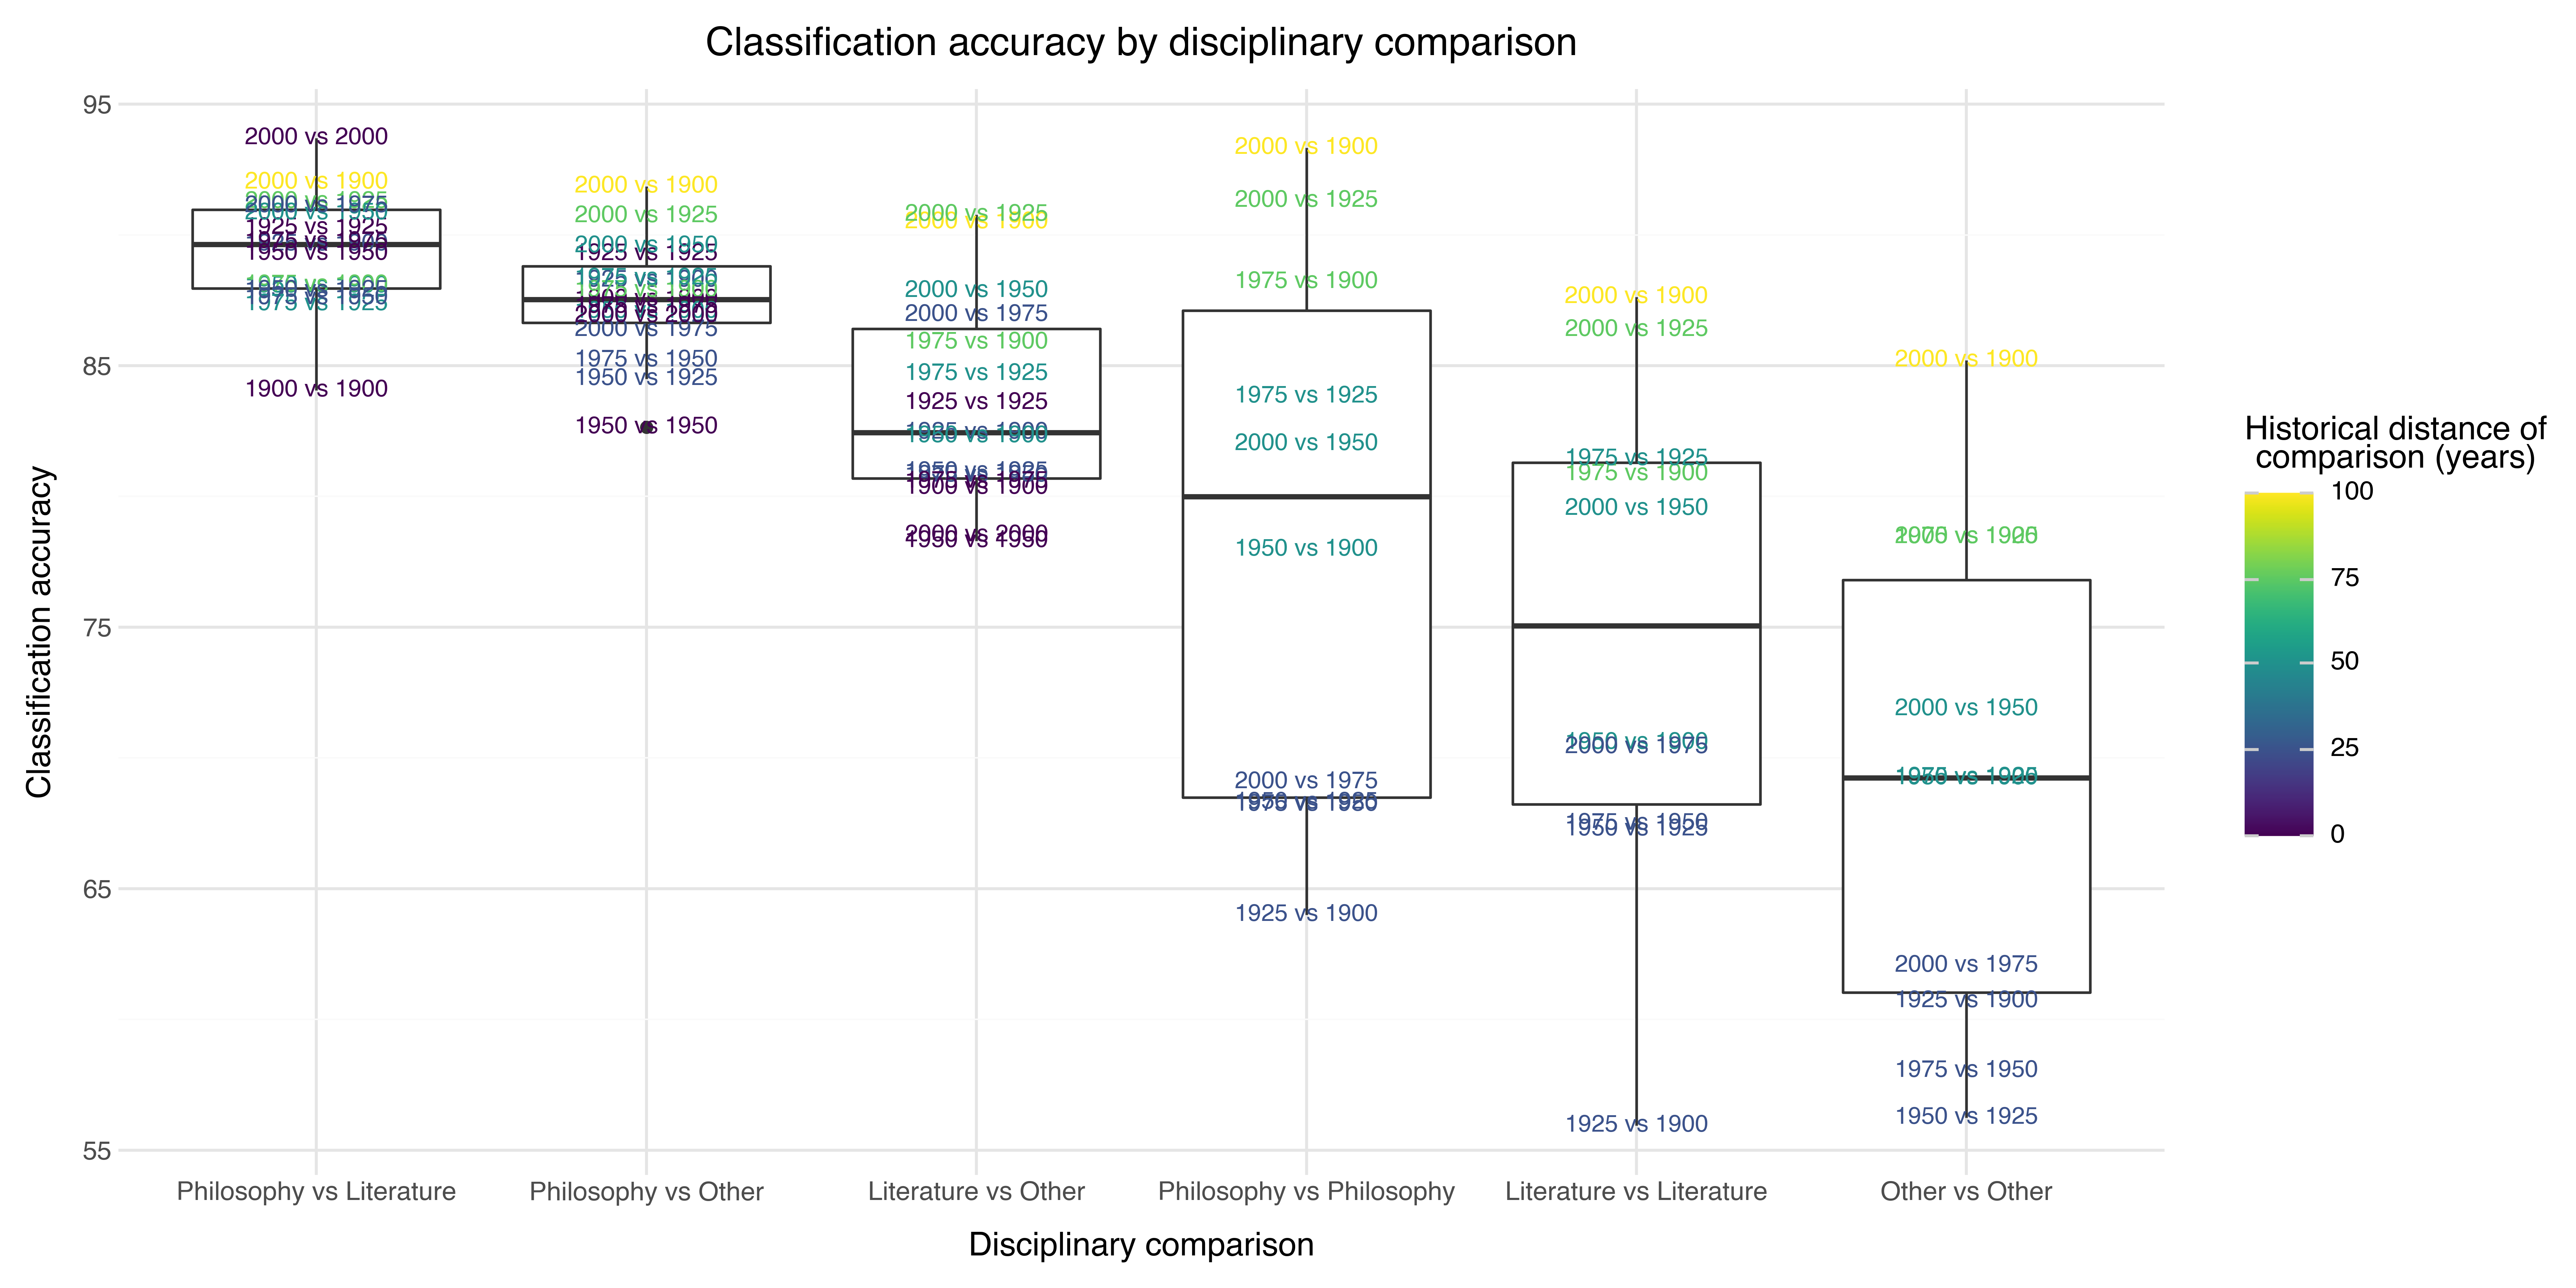

In [19]:
fig = (
    p9.ggplot(
        figdf,
        p9.aes(x='cmp_type', y='correct', label='period_type')
    ) 
    + p9.geom_boxplot() 
    + p9.theme_minimal() 
    + p9.theme(figure_size=(12, 6)) 
    + p9.geom_text(p9.aes(color='period_dist'), size=8)
    # + p9.scale_y_continuous(limits=(50, 100))
    + p9.labs(x='Disciplinary comparison', y='Classification accuracy', title='Classification accuracy by disciplinary comparison',color='Historical distance of\ncomparison (years)')
)
fig.save("../figures/classification_accuracy_by_comparison.png")
fig

In [20]:
# figdf['comparison'] = pd.Categorical(figdf['comparison'], categories=figdf.groupby('comparison').mean(numeric_only=True).sort_values('correct', ascending=False).index)
# fig = p9.ggplot(figdf, p9.aes(x='comparison', y='correct', fill='cmp_type', label='correct_str')) + p9.geom_bar(stat='identity') + p9.theme_minimal() + p9.coord_flip() + p9.theme(
#     figure_size=(10, 10),
# ) + p9.geom_text(size=8)
# fig